<a href="https://colab.research.google.com/github/deepakri201/SR_for_NLST_Sybil/blob/main/compare_to_nlstseg/NLST_compare_Sybil_vs_NLSTSeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compare the Sybil bounding boxes and the NLSTSeg segmentations

1. Find the SeriesInstanceUIDs that intersect
2. For comparing on a per slice basis:
- Find the ReferencedSOPInstanceUIDs from Sybil bounding boxes, and for NLSTSeg
- Find the ReferencedSOPInstanceUIDs that overlap
- Plot the bounding box and the segmentation for that slice  

Deepa Krishnaswamy

Brigham and Women's Hospital

September 2025

# Parameterization

In [1]:
#@title Enter your Project ID here
# initialize this variable with your Google Cloud Project ID!
project_name = "idc-external-018" #@param {type:"string"}

import os
os.environ["GCP_PROJECT_ID"] = project_name

!gcloud config set project $project_name

from google.colab import auth
auth.authenticate_user()

Updated property [core/project].


# Environment setup

In [2]:
!pip install idc-index

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 94.4 MB/s eta 0:00:00
  Attempting uninstall: duckdb
    Found existing installation: duckdb 1.3.2
    Uninstalling duckdb-1.3.2:
      Successfully uninstalled duckdb-1.3.2


In [3]:
import os
import sys
import time

import numpy as np
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

import json
from pathlib import Path

In [4]:
import matplotlib.patches as patches

In [5]:
from google.cloud import bigquery
from google.cloud import storage

In [6]:
import datetime

In [7]:
from idc_index import IDCClient

idc_client = IDCClient.client()

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [9]:
!pip install pydicom
import pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.1 MB/s eta 0:00:00


# Find the series that have both a bounding box and a segmentation

In [10]:
# Get the Referenced SeriesInstanceUIDs of the Sybil bounding boxes
client_bq = bigquery.Client(project=project_name)
query = f"""
  SELECT
    DISTINCT(ReferencedSeriesInstanceUID)
  FROM
    `idc-external-018.sr_nlst_sybil.bbox_measurements`
"""
df_sybil = client_bq.query(query).to_dataframe()

# Get the Referenced SeriesInstanceUIDs of the NLSTSeg
query = f"""
  SELECT
    DISTINCT(segmented_SeriesInstanceUID)
  FROM
    `idc-external-018.nlstseg_seg_and_sr.segmentations_100`
"""
df_nlstseg = client_bq.query(query).to_dataframe()

# Get the intersection
SeriesInstanceUIDs_list = list(set(df_sybil['ReferencedSeriesInstanceUID'].values) & set(df_nlstseg['segmented_SeriesInstanceUID'].values))

# Check
print('Sybil number of series: ' + str(len(df_sybil)))
print('NLSTSeg number of series: ' + str(len(df_nlstseg)))
print('Number of intersecting series: ' + str(len(SeriesInstanceUIDs_list)))



Sybil number of series: 970
NLSTSeg number of series: 100
Number of intersecting series: 77


# Pick a single series and get the overlapping slices

In [37]:
# Pick a single series

# series_pick = SeriesInstanceUIDs_list[0]
# print(series_pick)
series_pick = "1.2.840.113654.2.55.294795888751210912516507666864500510900"
print(series_pick)

1.2.840.113654.2.55.294795888751210912516507666864500510900


In [38]:
# Get a list of the Referenced SOPInstanceUIDs of the Sybil bounding boxes

query = f"""
  SELECT
    *
  FROM
    `idc-external-018.sr_nlst_sybil.bbox_measurements`
  WHERE
    ReferencedSeriesInstanceUID = @series_pick
"""
job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ScalarQueryParameter("series_pick", "STRING", series_pick)])
df_sybil_bbox = client_bq.query(query, job_config=job_config).to_dataframe()

# # Get a list of the Referenced SOPInstanceUIDs of the NLSTSeg
# query = f"""
#   SELECT
#     *
#   FROM
#     `idc-external-018.nlstseg_seg_and_sr.segmentations_100`
#   WHERE
#     segmented_SeriesInstanceUID = @series_pick
# """
# job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ScalarQueryParameter("series_pick", "STRING", series_pick)])
# df_nlstseg_seg = client_bq.query(query, job_config=job_config).to_dataframe()

query = f"""
  SELECT
    # rss.SeriesInstanceUID,
    ris.ReferencedSOPInstanceUID
  FROM
    `idc-external-018.nlstseg_seg_and_sr.dicom_all_100` AS dicom_all
  CROSS JOIN
    UNNEST(dicom_all.ReferencedSeriesSequence) AS rss
  CROSS JOIN
    UNNEST(rss.ReferencedInstanceSequence) AS ris
  WHERE
    # dicom_all.SeriesInstanceUID = @series_pick
    rss.SeriesInstanceUID = @series_pick
"""
job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ScalarQueryParameter("series_pick", "STRING", series_pick)])
df_nlstseg_seg = client_bq.query(query, job_config=job_config).to_dataframe()

# Get the intersection
SOPInstanceUIDs_list = list(set(df_sybil_bbox['ReferencedSOPInstanceUID'].values ) & set(df_nlstseg_seg['ReferencedSOPInstanceUID'].values))

# Check
print('Sybil number of referenced SOPInstanceUIDs: ' + str(len(df_sybil_bbox)))
print('NLSTSeg number of referenced SOPInstanceUIDs: ' + str(len(df_nlstseg_seg)))
print('Number of intersecting referenced SOPInstanceUIDs: ' + str(len(SOPInstanceUIDs_list)))

Sybil number of referenced SOPInstanceUIDs: 13
NLSTSeg number of referenced SOPInstanceUIDs: 11
Number of intersecting referenced SOPInstanceUIDs: 11


In [39]:
df_sybil_bbox

,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,ReferencedSeriesInstanceUID,trackingIdentifier,trackingUniqueIdentifier,finding,findingSite,ReferencedSOPInstanceUID,ConceptNameCodeSequence,GraphicType,x0,y0,x1,y1,x2,y2,x3,y3
0,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.826.0.1.3680043.8.498.68481923045020762558...,1.2.826.0.1.3680043.8.498.74147068248016160608...,1.2.840.113654.2.55.29479588875121091251650766...,1,1.2.826.0.1.3680043.8.498.45534493250266420451...,"{'CodeValue': '52988006', 'CodingSchemeDesigna...","{'CodeValue': '39607008', 'CodingSchemeDesigna...",1.2.840.113654.2.55.34236466855721118856467262...,"[{'CodeValue': '111030', 'CodingSchemeDesignat...",POLYLINE,114.645531,277.164215,189.445084,277.164215,189.445084,354.283112,114.645531,354.283112
1,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.826.0.1.3680043.8.498.68481923045020762558...,1.2.826.0.1.3680043.8.498.74147068248016160608...,1.2.840.113654.2.55.29479588875121091251650766...,2,1.2.826.0.1.3680043.8.498.28419090440338808943...,"{'CodeValue': '52988006', 'CodingSchemeDesigna...","{'CodeValue': '39607008', 'CodingSchemeDesigna...",1.2.840.113654.2.55.31650060872122281984513899...,"[{'CodeValue': '111030', 'CodingSchemeDesignat...",POLYLINE,115.000000,278.000000,189.000000,278.000000,189.000000,355.000000,115.000000,355.000000
2,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.826.0.1.3680043.8.498.68481923045020762558...,1.2.826.0.1.3680043.8.498.74147068248016160608...,1.2.840.113654.2.55.29479588875121091251650766...,3,1.2.826.0.1.3680043.8.498.56644835905616192347...,"{'CodeValue': '52988006', 'CodingSchemeDesigna...","{'CodeValue': '39607008', 'CodingSchemeDesigna...",1.2.840.113654.2.55.13998794245265636889281938...,"[{'CodeValue': '111030', 'CodingSchemeDesignat...",POLYLINE,115.000000,279.000000,189.000000,279.000000,189.000000,355.000000,115.000000,355.000000
3,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.826.0.1.3680043.8.498.68481923045020762558...,1.2.826.0.1.3680043.8.498.74147068248016160608...,1.2.840.113654.2.55.29479588875121091251650766...,4,1.2.826.0.1.3680043.8.498.74087784829532492234...,"{'CodeValue': '52988006', 'CodingSchemeDesigna...","{'CodeValue': '39607008', 'CodingSchemeDesigna...",1.2.840.113654.2.55.92014902492788269776983279...,"[{'CodeValue': '111030', 'CodingSchemeDesignat...",POLYLINE,116.000000,280.000000,190.000000,280.000000,190.000000,356.000000,116.000000,356.000000
4,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.826.0.1.3680043.8.498.68481923045020762558...,1.2.826.0.1.3680043.8.498.74147068248016160608...,1.2.840.113654.2.55.29479588875121091251650766...,5,1.2.826.0.1.3680043.8.498.60526965860971286229...,"{'CodeValue': '52988006', 'CodingSchemeDesigna...","{'CodeValue': '39607008', 'CodingSchemeDesigna...",1.2.840.113654.2.55.84705608724374715224219052...,"[{'CodeValue': '111030', 'CodingSchemeDesignat...",POLYLINE,116.000000,281.000000,189.000000,281.000000,189.000000,357.000000,116.000000,357.000000
5,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.826.0.1.3680043.8.498.68481923045020762558...,1.2.826.0.1.3680043.8.498.74147068248016160608...,1.2.840.113654.2.55.29479588875121091251650766...,6,1.2.826.0.1.3680043.8.498.34251908295188922556...,"{'CodeValue': '52988006', 'CodingSchemeDesigna...","{'CodeValue': '39607008', 'CodingSchemeDesigna...",1.2.840.113654.2.55.30065144618242790472755750...,"[{'CodeValue': '111030', 'CodingSchemeDesignat...",POLYLINE,116.000000,282.000000,189.000000,282.000000,189.000000,357.000000,116.000000,357.000000
6,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.826.0.1.3680043.8.498.68481923045020762558...,1.2.826.0.1.3680043.8.498.74147068248016160608...,1.2.840.113654.2.55.29479588875121091251650766...,7,1.2.826.0.1.3680043.8.498.36967847741999510803...,"{'CodeValue': '52988006', 'CodingSchemeDesigna...","{'CodeValue': '39607008', 'CodingSchemeDesigna...",1.2.840.11365

In [40]:
# Get the segmentation

In [41]:
# Get a list of the Referenced SOPInstanceUIDs of the NLSTSeg
query = f"""
  SELECT
    *
  FROM
    `idc-external-018.nlstseg_seg_and_sr.segmentations_100`
  WHERE
    segmented_SeriesInstanceUID = @series_pick
"""
job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ScalarQueryParameter("series_pick", "STRING", series_pick)])
df_seg = client_bq.query(query, job_config=job_config).to_dataframe()

In [42]:
df_seg

,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,FrameOfReferenceUID,SegmentedPropertyCategory,SegmentedPropertyType,SegmentAlgorithmType,SegmentAlgorithmName,SegmentNumber,segmented_SeriesInstanceUID
0,108245,1.2.840.113654.2.55.11302453418678226151499653...,1.2.276.0.7230010.3.1.3.481037312.86426.175814...,1.2.276.0.7230010.3.1.4.481037312.86426.175814...,1.2.840.113654.2.55.17943216027873288839087871...,"{'CodeValue': '49755003', 'CodingSchemeDesigna...","{'CodeValue': '8070', 'CodingSchemeDesignator'...",MANUAL,<NA>,1,1.2.840.113654.2.55.29479588875121091251650766...


In [43]:
# We get the segmentation file from the bucket
seg_filename_bucket = os.path.join("gs://nlstseg_seg_and_sr/seg", series_pick + "_SEG.dcm")
seg_filename = os.path.join("/content/seg", series_pick + "_SEG.dcm")
if not os.path.isdir("/content/seg"):
  os.mkdir("/content/seg")
!gsutil cp $seg_filename_bucket $seg_filename

Copying gs://nlstseg_seg_and_sr/seg/1.2.840.113654.2.55.294795888751210912516507666864500510900_SEG.dcm...
/ [1 files][361.4 KiB/361.4 KiB]                                                
Operation completed over 1 objects/361.4 KiB.                                    


In [44]:
# We know which slices have an overlap - by the referencedSOPInstanceUID
# Now we need to get the pixel data for those slices.

seg = pydicom.dcmread(seg_filename)

# Get the pixel array data
mask_data = seg.pixel_array
print(mask_data.shape)

# Need to get the per frame function groups - to know the referencedSOPInstanceUIDs
pffg = seg.PerFrameFunctionalGroupsSequence
num_slices_in_seg = len(pffg)
print('num_slices_in_seg: ' + str(num_slices_in_seg))
pffg_sop_list = []
for n in range(0,num_slices_in_seg):
  sop = pffg[n].DerivationImageSequence[0].SourceImageSequence[0].ReferencedSOPInstanceUID
  pffg_sop_list.append(sop)

# Now create a dataframe with the SOPInstanceUID and the slice index into mask
df_seg = pd.DataFrame()
df_seg['SOPInstanceUID'] = pffg_sop_list
df_seg['mask_slice'] = np.arange(0,len(pffg_sop_list))

(11, 512, 512)
num_slices_in_seg: 11


In [45]:
df_seg

,SOPInstanceUID,mask_slice
0,1.2.840.113654.2.55.13998794245265636889281938...,0
1,1.2.840.113654.2.55.92014902492788269776983279...,1
2,1.2.840.113654.2.55.84705608724374715224219052...,2
3,1.2.840.113654.2.55.30065144618242790472755750...,3
4,1.2.840.113654.2.55.33864278056094434912780366...,4
5,1.2.840.113654.2.55.82622644398986097265317855...,5
6,1.2.840.113654.2.55.24017737918811694854352532...,6
7,1.2.840.113654.2.55.19755032706118208307243774...,7
8,1.2.840.113654.2.55.66323297372561385302687603...,8
9,1.2.840.113654.2.55.29148859922133669813638716...,9


In [46]:
# Get the gcs_urls of the SOPInstanceUIDs_list - for plotting

query = f"""
  SELECT
    SOPInstanceUID,
    gcs_url
  FROM
    `bigquery-public-data.idc_current.dicom_all`
  WHERE
    SOPInstanceUID IN UNNEST(@SOPInstanceUIDs_list)
"""
job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ArrayQueryParameter("SOPInstanceUIDs_list", "STRING", SOPInstanceUIDs_list)])
df_sop_urls = client_bq.query(query, job_config=job_config).to_dataframe()


In [47]:
df_sop_urls

,SOPInstanceUID,gcs_url
0,1.2.840.113654.2.55.66323297372561385302687603...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
1,1.2.840.113654.2.55.29148859922133669813638716...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
2,1.2.840.113654.2.55.19755032706118208307243774...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
3,1.2.840.113654.2.55.82622644398986097265317855...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
4,1.2.840.113654.2.55.24017737918811694854352532...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
5,1.2.840.113654.2.55.84705608724374715224219052...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
6,1.2.840.113654.2.55.30065144618242790472755750...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
7,1.2.840.113654.2.55.33864278056094434912780366...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
8,1.2.840.113654.2.55.92014902492788269776983279...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...
9,1.2.840.113654.2.55.13998794245265636889281938...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...


In [48]:
# Now we join df_seg and df_sop_urls

df_plot = pd.merge(df_sop_urls, df_seg, left_on='SOPInstanceUID', right_on='SOPInstanceUID')

# Order by mask_slice
df_plot = df_plot.sort_values(by='mask_slice', ascending=True)

In [49]:
df_plot

,SOPInstanceUID,gcs_url,mask_slice
9,1.2.840.113654.2.55.13998794245265636889281938...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,0
8,1.2.840.113654.2.55.92014902492788269776983279...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,1
5,1.2.840.113654.2.55.84705608724374715224219052...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,2
6,1.2.840.113654.2.55.30065144618242790472755750...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,3
7,1.2.840.113654.2.55.33864278056094434912780366...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,4
3,1.2.840.113654.2.55.82622644398986097265317855...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,5
4,1.2.840.113654.2.55.24017737918811694854352532...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,6
2,1.2.840.113654.2.55.19755032706118208307243774...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,7
0,1.2.840.113654.2.55.66323297372561385302687603...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,8
1,1.2.840.113654.2.55.29148859922133669813638716...,gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff...,9


# Plot the bounding box and the seg on the overlapping slices

In [50]:
def tumor_fraction_in_box(mask, bbox):
  """
  mask: 2D numpy array (0/1 or bool) for tumor
  bbox: (xmin, ymin, xmax, ymax) in pixel coordinates
        (x = cols, y = rows)
  Returns: fraction of tumor voxels inside the box
  """
  xmin, ymin, xmax, ymax = bbox

  # clip to image bounds
  ymin = max(0, ymin); ymax = min(mask.shape[0], ymax)
  xmin = max(0, xmin); xmax = min(mask.shape[1], xmax)

  # box mask
  box_mask = np.zeros_like(mask, dtype=bool)
  box_mask[ymin:ymax, xmin:xmax] = True

  # intersection
  tumor_inside = np.logical_and(mask.astype(bool), box_mask)
  fraction = tumor_inside.sum() / mask.sum() if mask.sum() > 0 else np.nan

  return fraction


num_overlapping_slices: 11
num_rows: 2
num_columns: 11
Copying gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff7ee79016d/81259f75-d26f-43ee-835b-343580965534.dcm...
/ [1 files][514.0 KiB/514.0 KiB]                                                
Operation completed over 1 objects/514.0 KiB.                                    
bbox: [np.int16(115), np.int16(279), np.int16(189), np.int16(355)]
Copying gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff7ee79016d/eda73f66-1d22-4269-8fab-dd5957f2d410.dcm...
/ [1 files][514.0 KiB/514.0 KiB]                                                
Operation completed over 1 objects/514.0 KiB.                                    
bbox: [np.int16(116), np.int16(280), np.int16(190), np.int16(356)]
Copying gs://idc-open-data/2e0111bc-82e6-4285-8daa-cff7ee79016d/24074266-e514-4e26-92d1-cc61b69d1c01.dcm...
/ [1 files][514.0 KiB/514.0 KiB]                                                
Operation completed over 1 objects/514.0 KiB.                                   

/tmp/ipython-input-3858096735.py:100: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


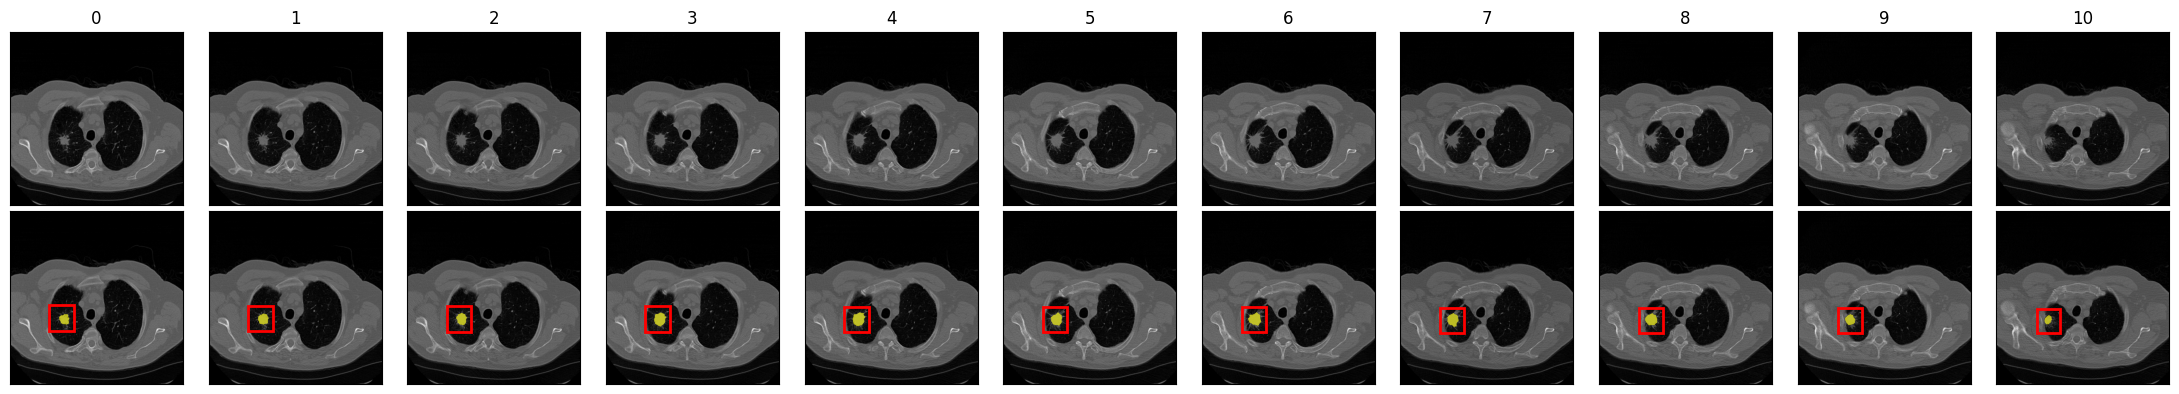

In [51]:
# num_overlapping_slices = len(SOPInstanceUIDs_list)
num_overlapping_slices = len(df_plot)
print('num_overlapping_slices: ' + str(num_overlapping_slices))

# Set figure layout based on this number
# num_rows = 2
# num_columns = np.int32(np.ceil(num_overlapping_slices/num_rows))
num_rows = 2
num_columns = num_overlapping_slices
print('num_rows: ' + str(num_rows))
print('num_columns: ' + str(num_columns))
fig, ax = plt.subplots(nrows=num_rows, ncols=num_columns, figsize=(num_overlapping_slices*2, 4), constrained_layout=True)

temp_directory = "/content/dicom"
if not os.path.isdir(temp_directory):
  os.mkdir(temp_directory)

# For each overlapping box/seg
# n = 0
# for row_index in range(0,num_rows):
  # for col_index in range(0,num_columns):

    # if (n == num_overlapping_slices):
    #   ax[row_index, col_index].axis("off")
    #   continue

metrics_list = []
for n in range(0,num_overlapping_slices):

  col_index = n

  # Get the referenced SOPInstanceUID
  # SOPInstanceUID = df_sop_urls['SOPInstanceUID'].values[n]
  SOPInstanceUID = df_plot['SOPInstanceUID'].values[n]

  # Download the single SOPInstanceUID
  # gcs_url = df_sop_urls['gcs_url'].values[n]
  gcs_url = df_plot['gcs_url'].values[n]
  ct_filename = os.path.join(temp_directory, 'sop.dcm')
  !gsutil cp $gcs_url $ct_filename

  # Get the CT data
  dcm = pydicom.dcmread(ct_filename)
  img = dcm.pixel_array

  # Get the bounding box coordinates
  df_temp = df_sybil_bbox[df_sybil_bbox['ReferencedSOPInstanceUID']==SOPInstanceUID]
  x0 = df_temp['x0'].values[0]; y0 = df_temp['y0'].values[0]
  x1 = df_temp['x1'].values[0]; y1 = df_temp['y1'].values[0]
  x2 = df_temp['x2'].values[0]; y2 = df_temp['y2'].values[0]
  x3 = df_temp['x3'].values[0]; y3 = df_temp['y3'].values[0]
  width = x1 - x0 # can change later
  height = y2 - y1 # can change later
  xmin = x0 # can change later
  ymin = y0 # can change later

  # Plot the CT image
  ax[0,col_index].imshow(img, cmap='gray')
  ax[0,col_index].get_xaxis().set_visible(False)
  ax[0,col_index].get_yaxis().set_visible(False)
  ax[0,col_index].set_title(str(n))
  row_index = 1
  ax[row_index,col_index].imshow(img, cmap='gray')
  ax[row_index,col_index].get_xaxis().set_visible(False)
  ax[row_index,col_index].get_yaxis().set_visible(False)

  # Create a Rectangle patch
  # The first argument is the (x, y) coordinates of the lower-left corner
  # The next two arguments are width and height
  # edgecolor sets the color of the box outline
  # facecolor sets the fill color (set to 'none' for no fill)
  # linewidth sets the thickness of the outline
  rect = patches.Rectangle((xmin, ymin), width, height,
                            edgecolor='red', facecolor='none', linewidth=2)
  ax[row_index,col_index].add_patch(rect)

  # Add the segmentation to the plot
  mask_slice = mask_data[n,:,:]
  # ax[row_index,col_index].imshow(mask_slice, cmap='Reds', alpha=0.3)
  overlay = np.zeros((*mask_slice.shape, 4))
  # overlay[mask_slice > 0] = (*plt.cm.get_cmap('Blues')(1)[:3], 0.3)  # RGB + alpha
  overlay[mask_slice > 0] = (1, 1, 0, 0.6)  # RGB + alpha
  ax[row_index,col_index].imshow(overlay)

  ### Calculate metrics ###
  # Calculate the percentage of the tumor that is inside the bounding box
  xmax = xmin + width
  ymax = ymin + height
  bbox = [np.floor(xmin).astype(np.int16),
          np.floor(ymin).astype(np.int16),
          np.ceil(xmax).astype(np.int16),
          np.ceil(ymax).astype(np.int16)]
  print('bbox: ' + str(bbox))
  metric = tumor_fraction_in_box(mask_slice, bbox)
  metrics_list.append(metric)

  # Increase index for the bounding boxes
  # n += 1

plt.tight_layout()
plt.show()

In [54]:
df_metrics = pd.DataFrame()
df_metrics['SOPInstanceUID'] = df_plot['SOPInstanceUID'].values
df_metrics['mask_slice'] = np.arange(0,len(df_plot))
df_metrics['metric'] = metrics_list

df_metrics

,SOPInstanceUID,mask_slice,metric
0,1.2.840.113654.2.55.13998794245265636889281938...,0,1.0
1,1.2.840.113654.2.55.92014902492788269776983279...,1,1.0
2,1.2.840.113654.2.55.84705608724374715224219052...,2,1.0
3,1.2.840.113654.2.55.30065144618242790472755750...,3,1.0
4,1.2.840.113654.2.55.33864278056094434912780366...,4,1.0
5,1.2.840.113654.2.55.82622644398986097265317855...,5,1.0
6,1.2.840.113654.2.55.24017737918811694854352532...,6,1.0
7,1.2.840.113654.2.55.19755032706118208307243774...,7,1.0
8,1.2.840.113654.2.55.66323297372561385302687603...,8,1.0
9,1.2.840.113654.2.55.29148859922133669813638716...,9,1.0
